# 04 — Model Training

**Purpose:** Run the training pipeline, inspect the raw model outputs, and tune the contamination parameter.

This notebook is interactive training — you run it when you want to experiment with model parameters. The production training flow (`src/aml_anomaly/models/train.py`) does the same thing non-interactively and saves the fitted objects to disk.

Key questions here:
- What do the raw Isolation Forest and Local Outlier Factor (LOF) score distributions look like?
- At the default `contamination=0.04`, are we flagging roughly the right number of accounts?
- If we adjust contamination, how does the precision on injected anomalies change?
- Does the ensemble score improve on either model alone?

In [1]:
import json
import sys
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import MinMaxScaler

sys.path.insert(0, str(Path.cwd().parent))

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)

DATA_DIR   = Path("../data")
MODELS_DIR = Path("../models")

In [2]:
features = pd.read_csv(DATA_DIR / "features" / "feature_matrix.csv")
injected = pd.read_csv(DATA_DIR / "raw" / "injected_anomalies.csv")
features["is_injected"] = features["account_id"].isin(injected["account_id"])

with open(MODELS_DIR / "scaler.pkl", "rb") as f:
    scaler = pickle.load(f)
with open(MODELS_DIR / "pca.pkl", "rb") as f:
    pca = pickle.load(f)

# Load the exact feature columns the model was trained on — the preprocessing
# pipeline may have dropped high-null features, so this list may be shorter
# than the full feature matrix. Using the wrong list causes a shape mismatch.
with open(MODELS_DIR / "feature_cols.json") as f:
    feature_cols = json.load(f)

X = features[feature_cols].fillna(features[feature_cols].median())
X_scaled = scaler.transform(X)
X_pca = pca.transform(X_scaled)

print(f"Training matrix: {X_pca.shape[0]} accounts × {X_pca.shape[1]} PCA components")

Training matrix: 2000 accounts × 20 PCA components


/Users/gabrielolson/projects/stock-trade-anomaly/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


## 1. Load fitted models and generate scores

In [3]:
with open(MODELS_DIR / "isolation_forest.pkl", "rb") as f:
    iso_forest = pickle.load(f)
with open(MODELS_DIR / "lof.pkl", "rb") as f:
    lof = pickle.load(f)

# Isolation Forest: score_samples returns negative scores — more negative = more anomalous
# We negate so higher = more anomalous (consistent with our convention)
if_raw_scores  = -iso_forest.score_samples(X_pca)
lof_raw_scores = -lof.score_samples(X_pca)

# Normalize each to [0, 1] for the ensemble
norm = MinMaxScaler()
if_norm  = norm.fit_transform(if_raw_scores.reshape(-1, 1)).flatten()
lof_norm = norm.fit_transform(lof_raw_scores.reshape(-1, 1)).flatten()

# Ensemble: 60% IF + 40% LOF
ensemble = 0.6 * if_norm + 0.4 * lof_norm

scores_df = pd.DataFrame({
    "account_id":       features["account_id"],
    "is_injected":      features["is_injected"],
    "if_score":         if_norm,
    "lof_score":        lof_norm,
    "anomaly_score":    ensemble,
})
scores_df["anomaly_rank"] = scores_df["anomaly_score"].rank(ascending=False).astype(int)
scores_df["anomaly_flag"] = (scores_df["anomaly_rank"] <= int(len(scores_df) * 0.04)).astype(int)

print(f"Flagged accounts (top 4%): {scores_df['anomaly_flag'].sum()}")

Flagged accounts (top 4%): 80


## 2. Score distributions

A healthy anomaly score distribution has a large mass of normal accounts near zero and a thin tail of anomalies at the high end. If the distribution is flat or bimodal, the model may not be finding a clear signal.

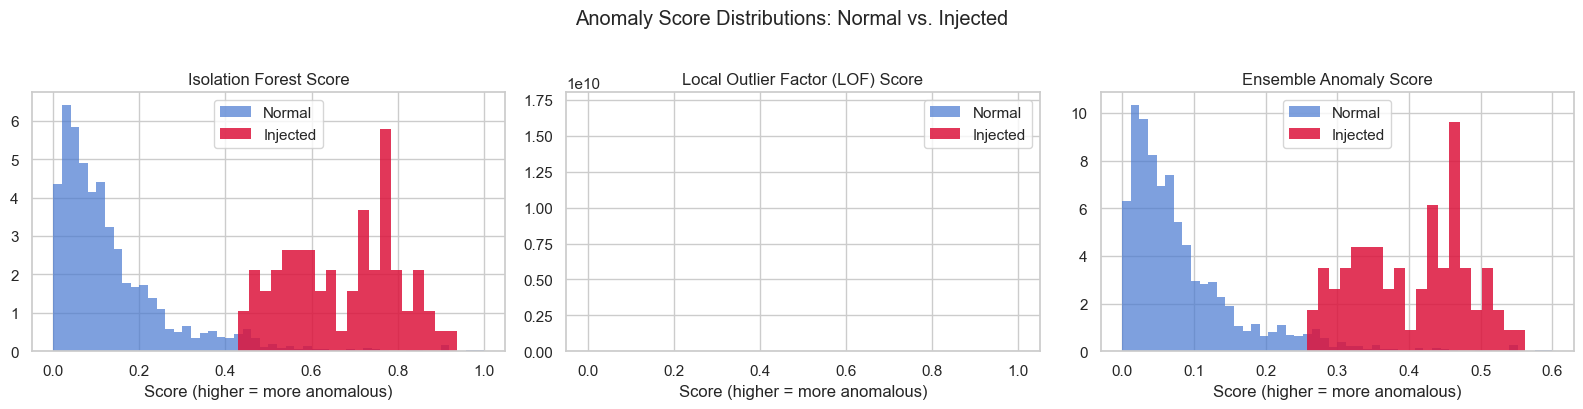

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col, title in zip(
    axes,
    ["if_score", "lof_score", "anomaly_score"],
    ["Isolation Forest Score", "Local Outlier Factor (LOF) Score", "Ensemble Anomaly Score"]
):
    normal_scores  = scores_df[~scores_df["is_injected"]][col]
    anomaly_scores = scores_df[scores_df["is_injected"]][col]

    ax.hist(normal_scores,  bins=50, alpha=0.7, label="Normal",   density=True, edgecolor="none")
    ax.hist(anomaly_scores, bins=20, alpha=0.85, label="Injected", color="crimson", density=True, edgecolor="none")
    ax.set_title(title)
    ax.set_xlabel("Score (higher = more anomalous)")
    ax.legend()

plt.suptitle("Anomaly Score Distributions: Normal vs. Injected", y=1.02)
plt.tight_layout()
plt.show()

## 3. Recall on injected anomalies

This is the key validation: of the accounts we *know* are anomalous (because we injected patterns into them), what fraction did the model catch?

**Recall** = injected accounts flagged ÷ total injected accounts

We also look at this by anomaly pattern — some patterns may be easier to detect than others.

In [5]:
scored_injected = scores_df[scores_df["is_injected"]].merge(
    injected[["account_id", "anomaly_pattern"]], on="account_id"
)

overall_recall = scored_injected["anomaly_flag"].mean()
print(f"Overall recall on injected anomalies: {overall_recall:.1%}")
print(f"  ({scored_injected['anomaly_flag'].sum()} of {len(scored_injected)} injected accounts flagged)")

print("\nRecall by anomaly pattern:")
by_pattern = scored_injected.groupby("anomaly_pattern")["anomaly_flag"].agg(["sum", "count"])
by_pattern["recall"] = by_pattern["sum"] / by_pattern["count"]
print(by_pattern.rename(columns={"sum": "flagged", "count": "total"}).to_string())

Overall recall on injected anomalies: 65.3%
  (49 of 75 injected accounts flagged)

Recall by anomaly pattern:
                        flagged  total    recall
anomaly_pattern                                 
illiquid_concentration       15     15  1.000000
off_hours_clustering          7     15  0.466667
smurfing                     15     15  1.000000
velocity_spike               11     15  0.733333
wash_trading                  1     15  0.066667


## 4. Precision at top K

Of the top-ranked accounts (most anomalous), what fraction are injected anomalies? This tells us how trustworthy the top of the list is for an analyst reviewing cases.

In [6]:
top_ks = [10, 20, 50, 80]
top_k_sorted = scores_df.sort_values("anomaly_score", ascending=False)

print("Precision at top K (% of top-K that are injected anomalies):")
for k in top_ks:
    precision = top_k_sorted.head(k)["is_injected"].mean()
    print(f"  Top {k:3d}: {precision:.1%}")

Precision at top K (% of top-K that are injected anomalies):
  Top  10: 20.0%
  Top  20: 50.0%
  Top  50: 68.0%
  Top  80: 61.3%


## 5. Contamination parameter sensitivity

The `contamination` parameter tells both models roughly what fraction of the dataset to expect as anomalies. Here we sweep it from 1% to 10% and see how recall and precision change — useful for deciding whether 4% is the right setting.

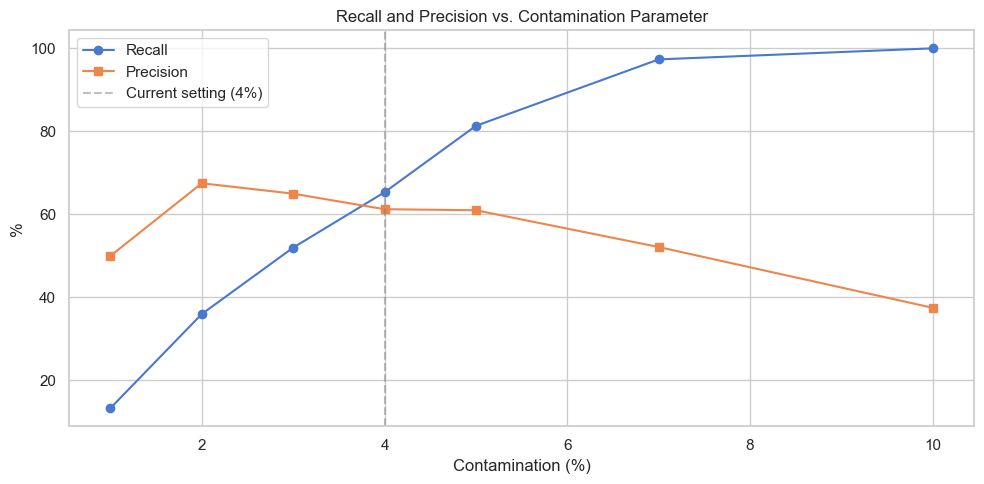

 contamination  n_flagged   recall  precision
          0.01         20 0.133333   0.500000
          0.02         40 0.360000   0.675000
          0.03         60 0.520000   0.650000
          0.04         80 0.653333   0.612500
          0.05        100 0.813333   0.610000
          0.07        140 0.973333   0.521429
          0.10        200 1.000000   0.375000


In [7]:
contamination_values = [0.01, 0.02, 0.03, 0.04, 0.05, 0.07, 0.10]
results = []

for c in contamination_values:
    n_flagged = int(len(scores_df) * c)
    top_n = scores_df.sort_values("anomaly_score", ascending=False).head(n_flagged)
    recall    = top_n["is_injected"].sum() / scores_df["is_injected"].sum()
    precision = top_n["is_injected"].mean()
    results.append({"contamination": c, "n_flagged": n_flagged, "recall": recall, "precision": precision})

results_df = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(results_df["contamination"] * 100, results_df["recall"] * 100, marker="o", label="Recall")
ax.plot(results_df["contamination"] * 100, results_df["precision"] * 100, marker="s", label="Precision")
ax.axvline(4, color="gray", linestyle="--", alpha=0.5, label="Current setting (4%)")
ax.set_xlabel("Contamination (%)")
ax.set_ylabel("%")
ax.set_title("Recall and Precision vs. Contamination Parameter")
ax.legend()
plt.tight_layout()
plt.show()

print(results_df.to_string(index=False))

## 6. Ensemble vs. individual model comparison

Does combining IF and LOF actually help? Compare the recall of each model alone against the ensemble.

In [8]:
n_flag = int(len(scores_df) * 0.04)

for model, col in [
    ("Isolation Forest",          "if_score"),
    ("Local Outlier Factor (LOF)", "lof_score"),
    ("Ensemble",                   "anomaly_score"),
]:
    top_n = scores_df.nlargest(n_flag, col)
    recall    = top_n["is_injected"].sum() / scores_df["is_injected"].sum()
    precision = top_n["is_injected"].mean()
    print(f"{model:<30}  recall: {recall:.1%}   precision: {precision:.1%}")

Isolation Forest                recall: 68.0%   precision: 63.7%
Local Outlier Factor (LOF)      recall: 29.3%   precision: 27.5%
Ensemble                        recall: 65.3%   precision: 61.3%
